# K-Nearest Neighbors (KNN) Demo

## Objective
This activity demonstrates how the K-Nearest Neighbors (KNN) algorithm works.

By the end of this demo, you should understand:
- How KNN uses distance to classify data
- Why feature scaling is important
- How the value of K affects the model

---

## Concept Overview

KNN is a **supervised learning algorithm** that classifies a data point based on the majority class of its nearest neighbors.

### Key Idea:
> "Similar data points are located close to each other."

---

## Real-Life Analogy

Imagine asking your closest friends whether a movie is good.
If most of them say it's good, you will likely agree.

That is exactly how KNN works.

Install dependencies:
    pip install numpy pandas matplotlib scikit-learn seaborn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Step 1: Create Dataset

We will use a simple dataset of students.

### Features:
- Hours Studied
- Attendance

### Target:
- Pass (1)
- Fail (0)

This makes it a **classification problem**.

In [2]:
# create sample dataset

data = {
    "hours_studied": [1,2,3,4,5,6,1,2,3,4,5,6],
    "attendance":    [50,60,70,80,90,95,40,55,65,75,85,92],
    "pass":          [0,0,0,1,1,1,0,0,0,1,1,1]
}

df = pd.DataFrame(data)
df

,hours_studied,attendance,pass
0,1,50,0
1,2,60,0
2,3,70,0
3,4,80,1
4,5,90,1
5,6,95,1
6,1,40,0
7,2,55,0
8,3,65,0
9,4,75,1


## Step 2: Visualize Data

We plot the dataset to observe how points are grouped.

- Each point represents a student
- Color represents whether they passed or failed

This helps us visually understand how KNN will classify data.

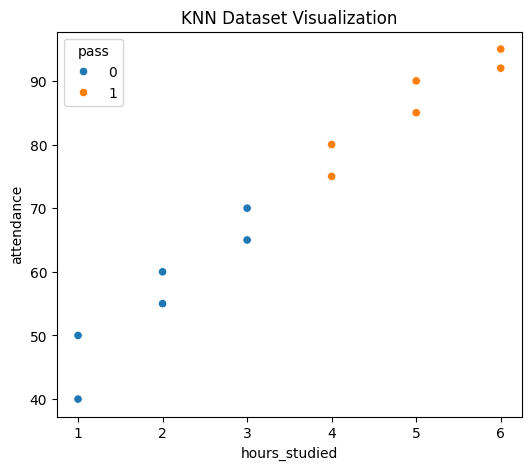

In [3]:
#visualize the data
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x="hours_studied", y="attendance", hue="pass")
plt.title("KNN Dataset Visualization")
plt.show()

## Step 3: Split the Dataset

We divide the dataset into:
- Training Set (used to train the model)
- Testing Set (used to evaluate performance)

Typical split:
- 70% Training
- 30% Testing

In [4]:
#split the data into features and target
X = df[["hours_studied", "attendance"]]
y = df["pass"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Step 4: Feature Scaling (Very Important)

KNN uses distance calculations.

If one feature has larger values (e.g., attendance),
it will dominate the distance calculation.

### Solution:
We standardize the features so they are on the same scale.

In [5]:
#Featrure Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 5: Train the KNN Model

We choose a value for K.

### Example:
K = 3 → the model looks at the 3 nearest neighbors

In [6]:
#train the KNN model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## Step 6: Make Predictions

The model predicts whether each test sample passes or fails.

In [7]:
#predict
y_pred = knn.predict(X_test_scaled)
y_pred

array([1, 1, 0, 0])

## Step 7: Evaluate the Model

We evaluate performance using:

- Accuracy → overall correctness
- Confusion Matrix → error breakdown
- Classification Report → precision, recall, F1-score

In [8]:
#evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[2 0]
 [0 2]]

Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



# Interpretation of Model Results

## Accuracy
The model achieved an **accuracy of 1.0 (100%)**, meaning all test samples were correctly classified. There were no prediction errors.

### Interpretation:
- **True Negatives (TN) = 2** → Correctly predicted *Fail*
- **True Positives (TP) = 2** → Correctly predicted *Pass*
- **False Positives (FP) = 0** → No incorrect *Pass* predictions
- **False Negatives (FN) = 0** → No missed *Pass* cases

The model made **zero errors** across all predictions.

---

## Classification Report

| Metric     | Class 0 (Fail) | Class 1 (Pass) |
|------------|---------------|---------------|
| Precision  | 1.00          | 1.00          |
| Recall     | 1.00          | 1.00          |
| F1-score   | 1.00          | 1.00          |
| Support    | 2             | 2             |

### Meaning:
- **Precision = 1.00** → All predicted labels are correct
- **Recall = 1.00** → All actual instances are correctly identified
- **F1-score = 1.00** → Perfect balance of precision and recall

---

## Important Insight
Although the results are perfect, this may not indicate a strong real-world model.

Possible reasons:
- The dataset is **very small (only 4 test samples)**
- The data is **simple and easy to separate**
- The model may be **overfitting**

---

## Conclusion
- The model performs perfectly on this dataset  
- However, it may **not generalize well** to new or more complex data  
- Further testing with larger datasets is recommended


## Step 8: Test a New Student

We input a new student and predict the result.

Example:
- Hours studied: 3
- Attendance: 70

In [9]:
#test new input
new_student = np.array([[3, 70]])
new_student_scaled = scaler.transform(new_student)

prediction = knn.predict(new_student_scaled)
print("Prediction (1=Pass, 0=Fail):", prediction[0])

Prediction (1=Pass, 0=Fail): 0


c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Step 9: Effect of Different K Values

We test different values of K to see how it affects performance.

### Key Insight:
- Small K → sensitive to noise (overfitting)
- Large K → smoother decision (underfitting)

In [10]:
#compare different k values
for k in [1,3,5]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    print(f"K={k}, Accuracy={accuracy_score(y_test, pred)}")

K=1, Accuracy=1.0
K=3, Accuracy=1.0
K=5, Accuracy=1.0


# Conclusion

### What we learned:
- KNN classifies data based on similarity (distance)
- Feature scaling is essential
- Choosing K affects performance

### When to Use KNN:
- Small datasets
- Low number of features
- When interpretability is not critical

### Limitations:
- Slow for large datasets
- Sensitive to irrelevant features